# Node Classification: GNN for Citation Networks (PyTorch Geometric)

This notebook builds a node classifier from scratch using a Graph Neural Network (GNN) over a citation graph. Dataset: **Cora** (2,708 papers, 1,433-dim bag-of-words features per paper, 10,556 citation links, 7 subject classes: Case_Based, Genetic_Algorithms, Neural_Networks, Probabilistic_Methods, Reinforcement_Learning, Rule_Learning, Theory).

Same overall pipeline as the CNN notebook, adapted for graph-structured data:
1. Get the data
2. Profile the data
3. Prepare the graph (features, edges, masks)
4. Split into train / validation / test
5. Build the model: GCNConv layers -> classifier head
6. Loss function & optimizer
7. Train, tracking train vs. validation loss/accuracy each epoch
8. Final evaluation on the held-out test set
9. Inference on a new node
10. Save the model

**The key difference from the CNN case:** images are independent samples that get batched, but here there is *one single graph* — every node's prediction depends on its neighbors' features via message passing. So instead of `DataLoader` batches of separate examples, we do **full-batch training**: one forward pass over the *entire* graph per epoch, and a boolean mask picks out which nodes' loss counts as "train" vs. "val" vs. "test" this step. This is called *transductive* learning — the model sees all nodes' features and all edges during training, it just isn't told the labels of val/test nodes.


## 0. Install & Import Libraries

In [1]:
# !pip install torch torch_geometric networkx scikit-learn matplotlib --quiet

import random
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx, degree
from torch_geometric.nn import GCNConv

from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 1. Get the Data

`torch_geometric.datasets.Planetoid` ships the Cora citation graph directly: each of the 2,708 nodes is a scientific paper, represented by a 1,433-dim binary bag-of-words vector (does the paper's vocabulary contain word *i*?). Each of the 10,556 (directed) edges is a citation between two papers. The task is to predict each paper's subject category — using *both* its own words *and* the categories of the papers it cites/is cited by.

Planetoid ships with a fixed, very small standard split (only 20 labeled nodes per class for training!) — that's fine for benchmarking against published results, but for this practice notebook we'll re-split the nodes ourselves further down, same "one-time random split" pattern used in the other notebooks, so we get a more typical 60/20/20 train/val/test ratio.


In [2]:
dataset = Planetoid(root="./data/Cora", name="Cora")
data = dataset[0]  # Cora is a single graph -> dataset has exactly one "example"

label_names = [
    "Theory", "Reinforcement_Learning", "Genetic_Algorithms",
    "Neural_Networks", "Probabilistic_Methods", "Case_Based", "Rule_Learning",
]
num_classes = dataset.num_classes
num_features = dataset.num_node_features

print("Graph:", data)
print("Number of nodes (papers):   ", data.num_nodes)
print("Number of edges (citations):", data.num_edges)
print("Node feature dimensionality:", num_features)
print("Number of classes:          ", num_classes)


Processing...


Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes (papers):    2708
Number of edges (citations): 10556
Node feature dimensionality: 1433
Number of classes:           7


Done!


## 2. Randomly Profile the Data

Same purpose as profiling the images/text in the other notebooks: check class balance, look at the connectivity, and sanity-check the feature values before building anything — catches obvious issues early (isolated nodes, degenerate features, wildly skewed classes).


In [3]:
unique, counts = np.unique(data.y.numpy(), return_counts=True)
print("Label distribution:")
for u, c in zip(unique, counts):
    print(f"  {label_names[u]:24s}: {c}")

node_degrees = degree(data.edge_index[0], num_nodes=data.num_nodes).numpy()
print("\nNode degree (citations per paper): min={:.0f}, mean={:.2f}, max={:.0f}".format(
    node_degrees.min(), node_degrees.mean(), node_degrees.max()))
print("Isolated nodes (degree 0):", int((node_degrees == 0).sum()))

print("\nFeature value range:", data.x.min().item(), "-", data.x.max().item(), "(binary bag-of-words)")
print("Avg number of words 'on' per paper:", data.x.sum(dim=1).mean().item())


Label distribution:
  Theory                  : 351
  Reinforcement_Learning  : 217
  Genetic_Algorithms      : 418
  Neural_Networks         : 818
  Probabilistic_Methods   : 426
  Case_Based              : 298
  Rule_Learning           : 180

Node degree (citations per paper): min=1, mean=3.90, max=168
Isolated nodes (degree 0): 0

Feature value range: 0.0 - 1.0 (binary bag-of-words)
Avg number of words 'on' per paper: 18.174299240112305


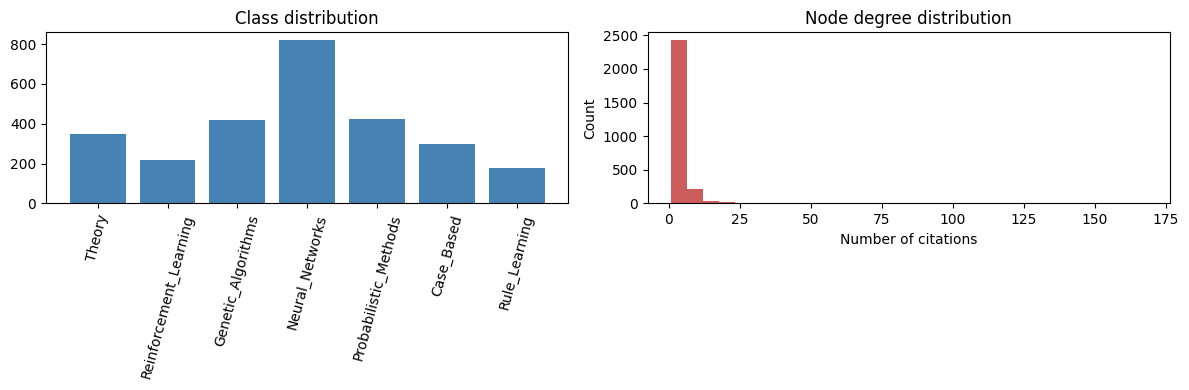

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([label_names[u] for u in unique], counts, color="steelblue")
axes[0].set_title("Class distribution")
axes[0].tick_params(axis="x", rotation=75)

axes[1].hist(node_degrees, bins=30, color="indianred")
axes[1].set_title("Node degree distribution")
axes[1].set_xlabel("Number of citations")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


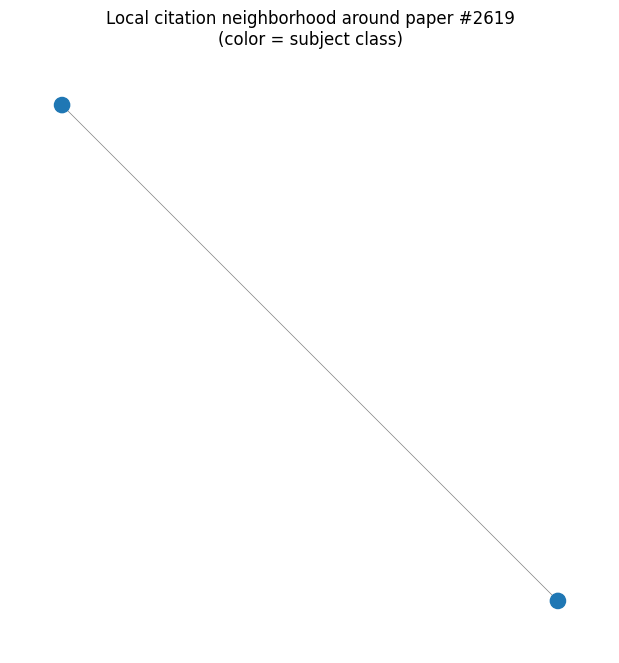

In [5]:
# Visualize a small random neighborhood of the citation graph, colored by class.
g = to_networkx(data, to_undirected=True)
center = random.choice(list(g.nodes))
neighborhood = {center} | set(g.neighbors(center))
for n in list(neighborhood):
    neighborhood |= set(g.neighbors(n))
subgraph = g.subgraph(list(neighborhood)[:60])

colors = [data.y[n].item() for n in subgraph.nodes]

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(subgraph, seed=SEED)
nx.draw(
    subgraph, pos, node_color=colors, cmap=plt.cm.tab10, node_size=120,
    with_labels=False, edge_color="gray", width=0.5,
)
plt.title(f"Local citation neighborhood around paper #{center}\n(color = subject class)")
plt.show()


## 3. Prepare the Graph Data

Unlike the image/text notebooks, there's no `Dataset`/`__getitem__` to write here — a GNN training step consumes the *whole graph at once* (`data.x` = all node features, `data.edge_index` = all edges), so there's nothing to lazily load per-sample. The only "preprocessing" step worth doing is normalizing each paper's bag-of-words vector by its row sum, so papers with more words don't dominate purely by vector magnitude.


In [6]:
row_sum = data.x.sum(dim=1, keepdim=True)
row_sum[row_sum == 0] = 1  # avoid divide-by-zero for any all-zero rows
data.x = data.x / row_sum

data = data.to(device)
print("Features normalized. New row sums (should all be ~1.0):", data.x.sum(dim=1)[:5])


Features normalized. New row sums (should all be ~1.0): tensor([1., 1., 1., 1., 1.], device='cuda:0')


## 4. Split into Train / Validation / Test

We ignore Planetoid's tiny built-in masks and build our own stratified 60/20/20 split over all 2,708 nodes — same spirit as pooling FashionMNIST's train+test and re-splitting. Masks are boolean tensors over node indices: `train_mask[i] = True` means node `i`'s label is visible to the loss function during training.


In [7]:
all_indices = np.arange(data.num_nodes)
labels_np = data.y.cpu().numpy()

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.4, stratify=labels_np, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=labels_np[temp_idx], random_state=SEED
)

def make_mask(indices, num_nodes):
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    mask[indices] = True
    return mask

train_mask = make_mask(train_idx, data.num_nodes).to(device)
val_mask = make_mask(val_idx, data.num_nodes).to(device)
test_mask = make_mask(test_idx, data.num_nodes).to(device)

print(f"Train nodes: {train_mask.sum().item()}")
print(f"Val nodes:   {val_mask.sum().item()}")
print(f"Test nodes:  {test_mask.sum().item()}")


Train nodes: 1624
Val nodes:   542
Test nodes:  542


## 5. Build the Model: Graph Convolutional Network

Direct analogy to the CNN:
- A `Conv2d` layer mixes each pixel with its **spatial** neighbors (a fixed 3x3 window) to build up features.
- A `GCNConv` layer mixes each node with its **graph** neighbors (whichever/however-many nodes it's connected to) to build up features. Stacking `k` `GCNConv` layers means each node's final representation is influenced by everything within `k` hops in the citation graph — same "receptive field grows with depth" idea as stacking conv blocks.

Architecture: `GCNConv -> ReLU -> Dropout` (x2) `-> GCNConv` (final layer maps straight to class logits — the GNN equivalent of the CNN's "global pool -> Linear" classifier head, except here every node gets its own logits directly, there's no pooling since we're classifying nodes, not the whole graph).


In [8]:
class GCNNodeClassifier(nn.Module):
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        logits = self.conv3(x, edge_index)  # (num_nodes, num_classes)
        return logits


In [9]:
model = GCNNodeClassifier(
    in_features=num_features,
    hidden_dim=64,
    num_classes=num_classes,
    dropout=0.5,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 96,391
Trainable params: 96,391


## 6. Loss Function & Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


## 7. Training Loop

No `DataLoader` here — each "epoch" is a single forward/backward pass over the *entire* graph, then the loss/accuracy is computed separately on the `train_mask`, `val_mask` nodes from that same forward pass. This is the full-batch, transductive training pattern almost all introductory GNN node-classification tasks use.


In [11]:
def train_one_epoch(model, data, optimizer, criterion, train_mask):
    model.train()
    optimizer.zero_grad()

    logits = model(data.x, data.edge_index)
    loss = criterion(logits[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    preds = logits[train_mask].argmax(dim=1)
    acc = (preds == data.y[train_mask]).float().mean().item()
    return loss.item(), acc


In [12]:
@torch.no_grad()
def evaluate(model, data, criterion, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    loss = criterion(logits[mask], data.y[mask]).item()
    preds = logits[mask].argmax(dim=1)
    acc = (preds == data.y[mask]).float().mean().item()
    return loss, acc


In [13]:
NUM_EPOCHS = 100

history = []

progress_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs")
for epoch in progress_bar:
    train_loss, train_acc = train_one_epoch(model, data, optimizer, criterion, train_mask)
    val_loss, val_acc = evaluate(model, data, criterion, val_mask)   # validation, NOT test

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })

    progress_bar.set_postfix(train_loss=train_loss, train_acc=train_acc, val_acc=val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 | Train Loss: 1.9460, Train Acc: 0.1188 | Val Loss: 1.9259, Val Acc: 0.3026
Epoch 10/100 | Train Loss: 1.7544, Train Acc: 0.3023 | Val Loss: 1.7517, Val Acc: 0.3026
Epoch 20/100 | Train Loss: 1.4444, Train Acc: 0.4514 | Val Loss: 1.4265, Val Acc: 0.4779
Epoch 30/100 | Train Loss: 1.0843, Train Acc: 0.6312 | Val Loss: 1.0593, Val Acc: 0.6144
Epoch 40/100 | Train Loss: 0.8092, Train Acc: 0.7321 | Val Loss: 0.8152, Val Acc: 0.7288
Epoch 50/100 | Train Loss: 0.6488, Train Acc: 0.7882 | Val Loss: 0.6538, Val Acc: 0.7915
Epoch 60/100 | Train Loss: 0.5030, Train Acc: 0.8344 | Val Loss: 0.5662, Val Acc: 0.8155
Epoch 70/100 | Train Loss: 0.4232, Train Acc: 0.8842 | Val Loss: 0.5081, Val Acc: 0.8542
Epoch 80/100 | Train Loss: 0.3643, Train Acc: 0.8953 | Val Loss: 0.4812, Val Acc: 0.8598
Epoch 90/100 | Train Loss: 0.3292, Train Acc: 0.9089 | Val Loss: 0.4399, Val Acc: 0.8893
Epoch 100/100 | Train Loss: 0.2949, Train Acc: 0.9132 | Val Loss: 0.4355, Val Acc: 0.8801


## 7a. Plot Training & Validation Curves

Same read as always: a widening gap (train accuracy climbing, val flat or dropping) signals overfitting; both curves plateauing together suggests convergence. GCNs on small citation graphs tend to overfit fast because there are relatively few labeled training nodes — that's exactly what `Dropout` and `weight_decay` above are fighting against.


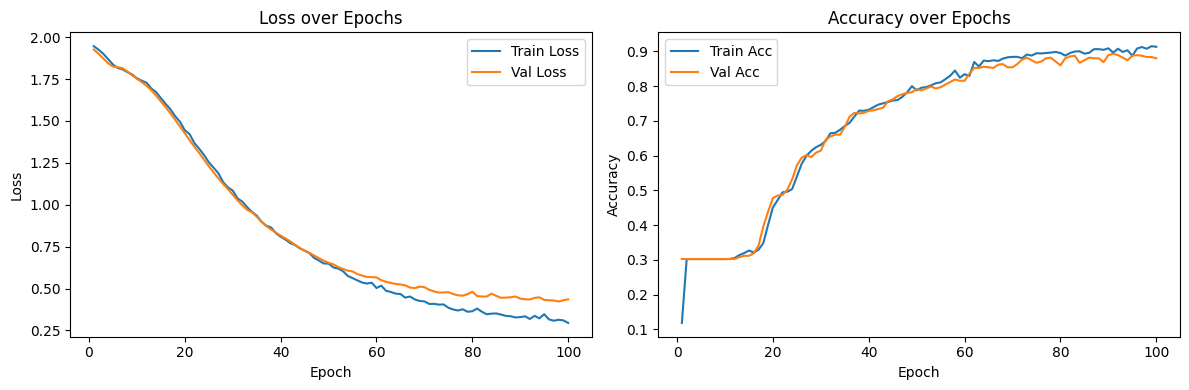

In [14]:
epochs = [h["epoch"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]
train_accs = [h["train_acc"] for h in history]
val_accs = [h["val_acc"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label="Train Loss")
axes[0].plot(epochs, val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()

axes[1].plot(epochs, train_accs, label="Train Acc")
axes[1].plot(epochs, val_accs, label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Final Evaluation on the Test Set

The test mask was never touched during training or model selection above — this is the one-shot, held-out number that estimates real-world performance.


In [15]:
test_loss, test_acc = evaluate(model, data, criterion, test_mask)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


Test Loss: 0.4057 | Test Accuracy: 0.8801


## 9. Inference on a New Node

Pick a single test-set paper, show what it cites/is cited by (its graph neighborhood — the extra information a GNN has access to that a plain feature-only classifier wouldn't), and compare the model's predicted subject category against the true one.


In [16]:
@torch.no_grad()
def predict_node(model, data, node_idx, label_names):
    model.eval()
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits[node_idx], dim=0)
    pred_class = probs.argmax().item()
    confidence = probs[pred_class].item()
    return label_names[pred_class], confidence


random_test_idx = random.choice(test_idx.tolist())
pred_label, confidence = predict_node(model, data, random_test_idx, label_names)
true_label = label_names[data.y[random_test_idx].item()]

neighbors = g.neighbors(random_test_idx)
neighbor_classes = [label_names[data.y[n].item()] for n in neighbors]

print(f"Paper #{random_test_idx}")
print(f"  True subject:      {true_label}")
print(f"  Predicted subject: {pred_label} (confidence: {confidence:.4f})")
print(f"  Cites / cited by {len(neighbor_classes)} other paper(s), with subjects: {neighbor_classes}")


Paper #1576
  True subject:      Neural_Networks
  Predicted subject: Neural_Networks (confidence: 0.9370)
  Cites / cited by 2 other paper(s), with subjects: ['Neural_Networks', 'Neural_Networks']


## 10. Save the Model (optional)

In [17]:
torch.save(model.state_dict(), "gcn_node_classifier.pt")
print("Model saved to gcn_node_classifier.pt")

# To reload later:
# model = GCNNodeClassifier(in_features=num_features, hidden_dim=64, num_classes=num_classes, dropout=0.5)
# model.load_state_dict(torch.load("gcn_node_classifier.pt", map_location=device))
# model.to(device)


Model saved to gcn_node_classifier.pt
